# Parcial #2
- Juan Pablo Betancur Zuluaga

- Santiago Pareja Pareja

In [18]:
import numpy as np
import pandas as pd
import control as ct
import matplotlib.pyplot as plt
from scipy.optimize import minimize

## Escalón en calentador 1 y 2

Los datos obtenidos son con un escalón del 20%, que fueron los obtenidos en del primer laboratorio.

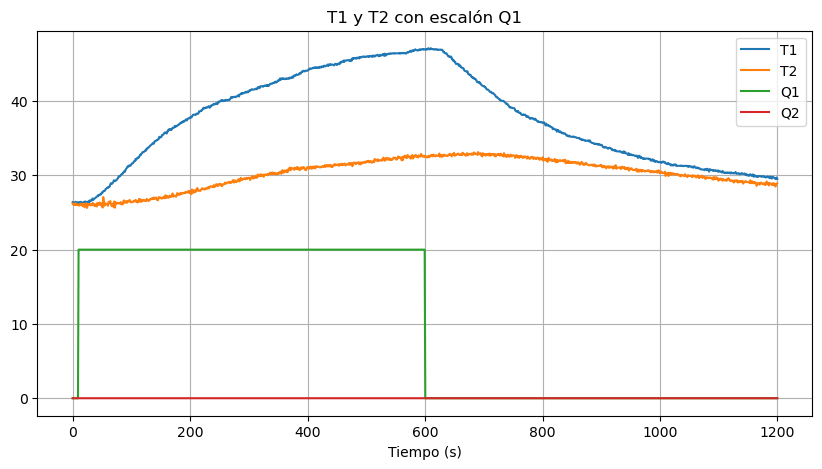

In [19]:
ruta = "data_Q1.txt"
data = pd.read_csv(ruta, encoding='latin1', sep=',')

#print(data.head())
#print(len(data))
#print(data.columns)

t = data["Tiempo (s)"]
tempQ1 = data[" Temp1 (°C)"]
tempQ2 = data[" Temp2 (°C)"]
u1 = data[" Cal1 (%)"]
u2 = data[" Cal2 (%)"]

plt.figure(figsize=(10,5))
plt.title("T1 y T2 con escalón Q1")
plt.plot(t,tempQ1,label="T1")
plt.plot(t,tempQ2,label="T2")
plt.plot(t,u1,label="Q1")
plt.plot(t,u2,label="Q2")

plt.xlabel("Tiempo (s)")

plt.legend()
plt.grid()
plt.show()

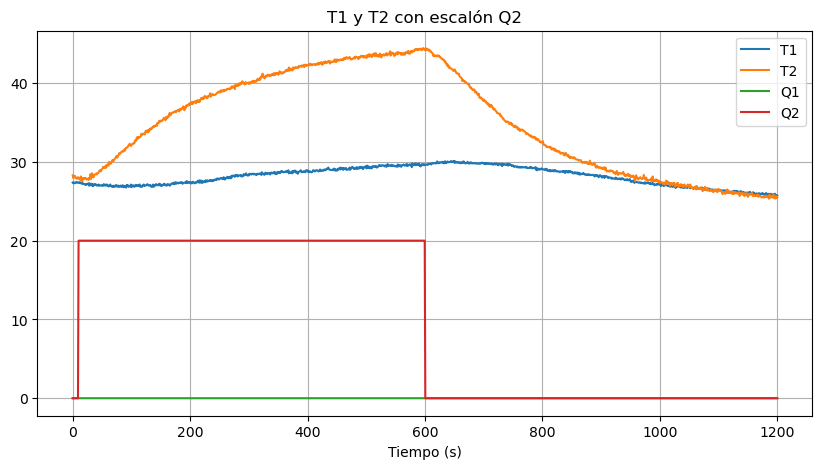

In [20]:
ruta = "data_Q2.txt"
data = pd.read_csv(ruta, encoding='latin1', sep=',')

#print(data.head())
#print(len(data))
#print(data.columns)

t = data["Tiempo (s)"]
tempQ1 = data[" Temp1 (°C)"]
tempQ2 = data[" Temp2 (°C)"]
u1 = data[" Cal1 (%)"]
u2 = data[" Cal2 (%)"]

plt.figure(figsize=(10,5))
plt.title("T1 y T2 con escalón Q2")
plt.plot(t,tempQ1,label="T1")
plt.plot(t,tempQ2,label="T2")
plt.plot(t,u1,label="Q1")
plt.plot(t,u2,label="Q2")

plt.xlabel("Tiempo (s)")

plt.legend()
plt.grid()
plt.show()

## Obtención de funciones de transferencia por medio del metodo de Optimización

Por medio del método de optimización se obtienen las respectivas funciones de transferencia:
$$
G_{11}=\frac{1.2239}{287.40s+1}e^{-15.14s}
$$

$$
G_{12}=\frac{0.1008}{69.21s+1}e^{-222.94s}
$$

$$
G_{22}=\frac{0.7420}{117.45s+1}e^{-51.45s}
$$

$$
G_{21}=\frac{0.5672}{569.45s+1}e^{-86.51s}
$$


──────────────────────────────────────────────────
  G11: T1 ← Q1  |  ON t=9.0s  du=20.00%  OFF t=599.3s
  K=1.2239  τ=287.40s  θ=15.14s
  R² vs media    = 0.9970
  R² vs simulado = 0.9971


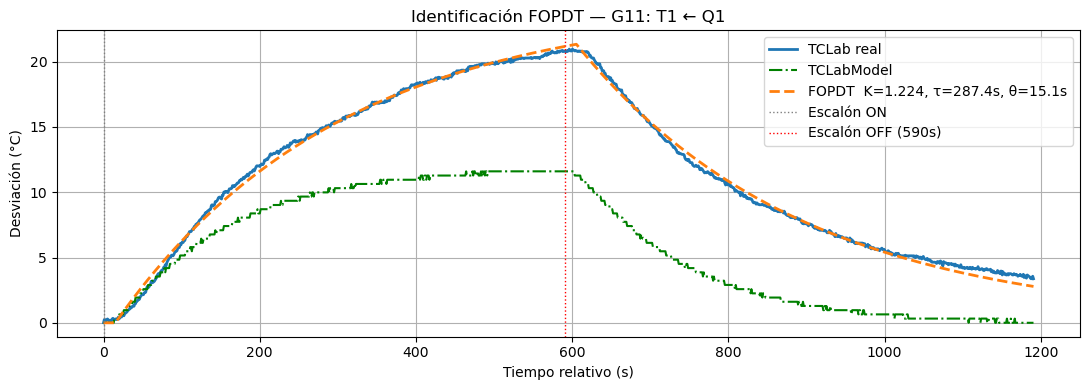


──────────────────────────────────────────────────
  G21: T2 ← Q1  |  ON t=9.0s  du=20.00%  OFF t=599.3s
  K=0.5672  τ=569.45s  θ=86.51s
  R² vs media    = 0.9883
  R² vs simulado = 0.9966


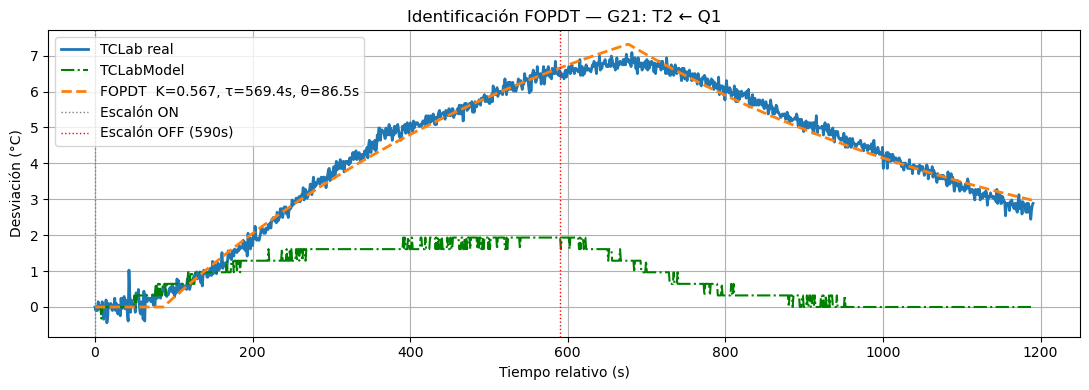


──────────────────────────────────────────────────
  G12: T1 ← Q2  |  ON t=9.0s  du=20.00%  OFF t=599.4s
  K=0.1008  τ=69.21s  θ=222.94s
  R² vs media    = 0.8116
  R² vs simulado = 0.7548


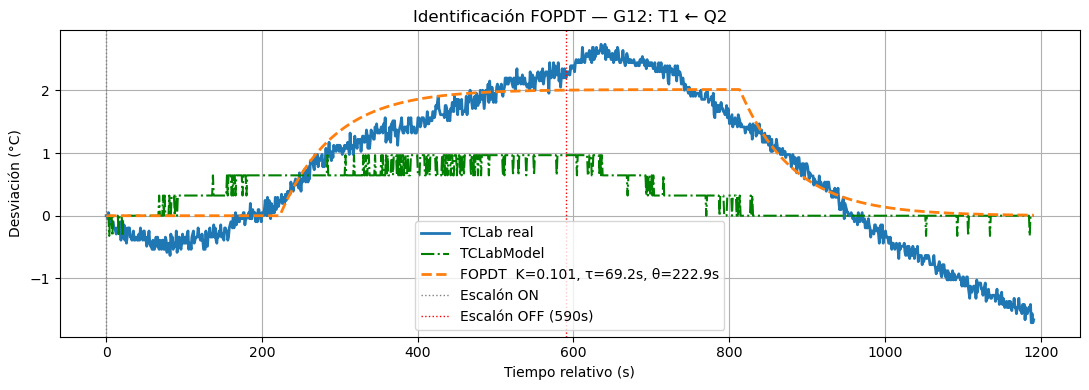


──────────────────────────────────────────────────
  G22: T2 ← Q2  |  ON t=9.0s  du=20.00%  OFF t=599.4s
  K=0.7420  τ=117.45s  θ=51.45s
  R² vs media    = 0.9696
  R² vs simulado = 0.9639


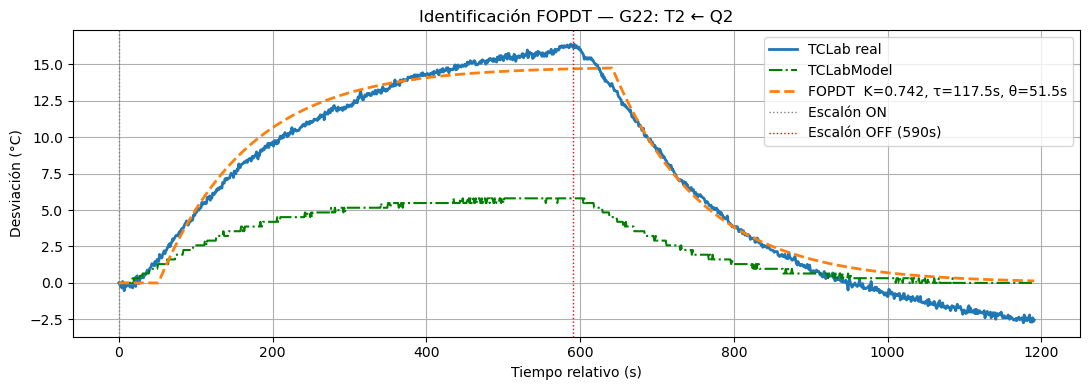


═════════════════════════════════════════════════════════════════
  MATRIZ DE TRANSFERENCIA G(s)
═════════════════════════════════════════════════════════════════
  G11(s) = (1.2239 · e^(-15.14s)) / (287.40s + 1)
         R² vs media=0.9970   R² vs simulado=0.9971

  G21(s) = (0.5672 · e^(-86.51s)) / (569.45s + 1)
         R² vs media=0.9883   R² vs simulado=0.9966

  G12(s) = (0.1008 · e^(-222.94s)) / (69.21s + 1)
         R² vs media=0.8116   R² vs simulado=0.7548

  G22(s) = (0.7420 · e^(-51.45s)) / (117.45s + 1)
         R² vs media=0.9696   R² vs simulado=0.9639

═════════════════════════════════════════════════════════════════


In [21]:
# ─────────────────────────────────────────
# FUNCIONES
# ─────────────────────────────────────────
def detectar_escalon(u, umbral_factor=0.3):
    du_signal = np.diff(u)
    umbral    = umbral_factor * (u.max() - u.min())
    idx_on    = np.argmax(np.abs(du_signal) > umbral)
    idx_off   = idx_on + 1 + np.argmax(np.abs(du_signal[idx_on+1:]) > umbral)
    return idx_on, idx_off

def simulate_fopdt_onoff(t, K, tau, theta, du, t_off_rel):
    y = np.zeros_like(t, dtype=float)
    for i, ti in enumerate(t):
        if ti >= theta:
            y[i] += K * du * (1 - np.exp(-(ti - theta) / tau))
        t_off_theta = t_off_rel + theta
        if ti >= t_off_theta:
            y[i] -= K * du * (1 - np.exp(-(ti - t_off_theta) / tau))
    return y

def calcular_r2(y_real, y_modelo, y_simulado=None):
    SSres       = np.sum((y_real - y_modelo) ** 2)
    SStot_media = np.sum((y_real - y_real.mean()) ** 2)
    r2_media    = 1 - SSres / SStot_media
    if y_simulado is not None:
        SStot_sim = np.sum((y_real - y_simulado) ** 2)
        r2_sim    = 1 - SSres / SStot_sim
        return r2_media, r2_sim
    return r2_media, None

def identificar(t, y_out, u_in, y_sim, nombre="G"):
    """Identificación completa de una FOPDT
       y_sim: señal equivalente del TCLabModel (ya recortada igual que y_out)
    """
    idx_on, idx_off = detectar_escalon(u_in)
    t_on      = t[idx_on]
    t_off     = t[idx_off]
    du        = u_in[idx_on+1] - u_in[idx_on]
    y0        = y_out[idx_on]
    y0_sim    = y_sim[idx_on]

    t_id      = t[idx_on:] - t_on
    y_id      = y_out[idx_on:] - y0
    y_id_sim  = y_sim[idx_on:] - y0_sim   # desviación del simulado
    t_off_rel = t_off - t_on

    print(f"\n{'─'*50}")
    print(f"  {nombre}  |  ON t={t_on:.1f}s  du={du:.2f}%  OFF t={t_off:.1f}s")

    # Estimación inicial (Smith)
    idx_peak   = np.argmax(y_id)
    y_inf      = y_id[idx_peak]
    K0         = y_inf / du
    y28, y63   = 0.283 * y_inf, 0.632 * y_inf
    t28 = t_id[np.argmin(np.abs(y_id[:idx_peak+1] - y28))]
    t63 = t_id[np.argmin(np.abs(y_id[:idx_peak+1] - y63))]
    tau0   = max(1.5 * (t63 - t28), 1.0)
    theta0 = max(t63 - tau0, 0.0)

    # Optimización
    def cost(params):
        K, tau, theta = params
        if tau <= 0 or theta < 0:
            return 1e10
        y_model = simulate_fopdt_onoff(t_id, K, tau, theta, du, t_off_rel)
        return np.sum((y_id - y_model) ** 2)

    result = minimize(cost, [K0, tau0, theta0], method='L-BFGS-B',
                      bounds=[(0.001, None), (1.0, None), (0.0, None)],
                      options={'maxiter': 10000, 'ftol': 1e-14})

    K_opt, tau_opt, theta_opt = result.x
    y_fit = simulate_fopdt_onoff(t_id, K_opt, tau_opt, theta_opt, du, t_off_rel)

    # R² de ambas formas
    r2_media, r2_sim = calcular_r2(y_id, y_fit, y_simulado=y_id_sim)

    print(f"  K={K_opt:.4f}  τ={tau_opt:.2f}s  θ={theta_opt:.2f}s")
    print(f"  R² vs media    = {r2_media:.4f}")
    print(f"  R² vs simulado = {r2_sim:.4f}")

    # Gráfica
    plt.figure(figsize=(11, 4))
    plt.title(f"Identificación FOPDT — {nombre}")
    plt.plot(t_id, y_id,     label="TCLab real",      linewidth=2)
    plt.plot(t_id, y_id_sim, label="TCLabModel",       linewidth=1.5, linestyle='-.',  color='green')
    plt.plot(t_id, y_fit,    label=f"FOPDT  K={K_opt:.3f}, τ={tau_opt:.1f}s, θ={theta_opt:.1f}s",
             linestyle='--', linewidth=2)
    plt.axvline(0,         color='gray', linestyle=':', linewidth=1, label="Escalón ON")
    plt.axvline(t_off_rel, color='red',  linestyle=':', linewidth=1, label=f"Escalón OFF ({t_off_rel:.0f}s)")
    plt.xlabel("Tiempo relativo (s)")
    plt.ylabel("Desviación (°C)")
    plt.legend(); plt.grid(); plt.tight_layout(); plt.show()

    return {
        'K': K_opt, 'tau': tau_opt, 'theta': theta_opt,
        'R2_media': r2_media, 'R2_sim': r2_sim,
        'y_real': y_id, 'y_fit': y_fit, 'y_sim': y_id_sim
    }

# ─────────────────────────────────────────
# CARGAR DATOS REALES Y SIMULADOS
# ─────────────────────────────────────────
d1     = pd.read_csv("data_Q1.txt",     encoding='latin1', sep=',')
d1_sim = pd.read_csv("data_Q1_sim.txt", encoding='latin1', sep=',')
d2     = pd.read_csv("data_Q2.txt",     encoding='latin1', sep=',')
d2_sim = pd.read_csv("data_Q2_sim.txt", encoding='latin1', sep=',')

t1 = d1["Tiempo (s)"].values
T1_q1 = d1[" Temp1 (°C)"].values;  T2_q1 = d1[" Temp2 (°C)"].values
u1    = d1[" Cal1 (%)"].values

T1_q1_sim = d1_sim[" Temp1 (°C)"].values;  T2_q1_sim = d1_sim[" Temp2 (°C)"].values

t2 = d2["Tiempo (s)"].values
T1_q2 = d2[" Temp1 (°C)"].values;  T2_q2 = d2[" Temp2 (°C)"].values
u2    = d2[" Cal2 (%)"].values

T1_q2_sim = d2_sim[" Temp1 (°C)"].values;  T2_q2_sim = d2_sim[" Temp2 (°C)"].values

# ─────────────────────────────────────────
# IDENTIFICAR LAS 4 FUNCIONES
# ─────────────────────────────────────────
G11 = identificar(t1, T1_q1, u1, T1_q1_sim, "G11: T1 ← Q1")
G21 = identificar(t1, T2_q1, u1, T2_q1_sim, "G21: T2 ← Q1")
G12 = identificar(t2, T1_q2, u2, T1_q2_sim, "G12: T1 ← Q2")
G22 = identificar(t2, T2_q2, u2, T2_q2_sim, "G22: T2 ← Q2")

# ─────────────────────────────────────────
# RESUMEN FINAL
# ─────────────────────────────────────────
print("\n" + "═"*65)
print("  MATRIZ DE TRANSFERENCIA G(s)")
print("═"*65)
for nombre, g in [("G11", G11), ("G21", G21), ("G12", G12), ("G22", G22)]:
    print(f"  {nombre}(s) = ({g['K']:.4f} · e^(-{g['theta']:.2f}s)) / ({g['tau']:.2f}s + 1)")
    print(f"         R² vs media={g['R2_media']:.4f}   R² vs simulado={g['R2_sim']:.4f}")
    print()
print("═"*65)

### Construcción de las funciones de transferencia y su respuesta al escalón

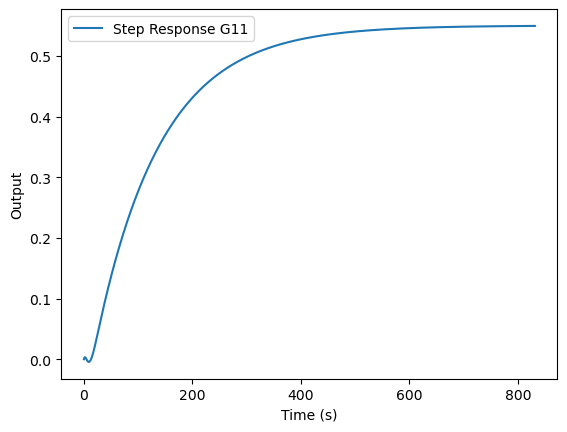

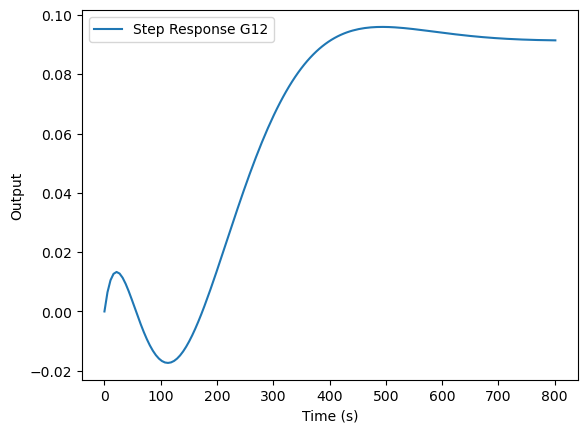

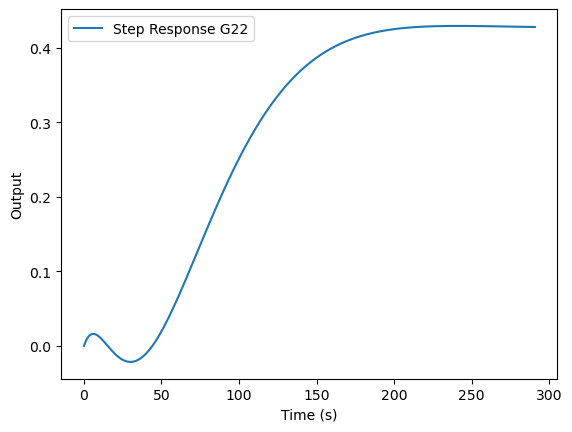

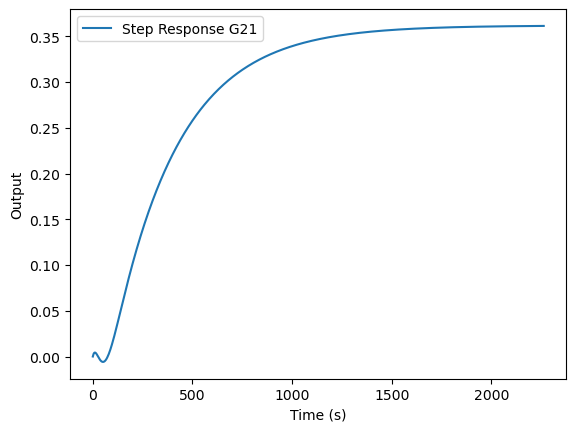

In [22]:
s = ct.TransferFunction.s

k11 = 1.2239; tau11 = 287.40; theta11 = 15.14
k21 = 0.5672; tau21 = 569.45; theta21 = 86.51
k12 = 0.1008; tau12 = 69.21;  theta12 = 222.94
k22 = 0.7420; tau22 = 117.45; theta22 = 51.45

def pade_delay(theta, order=2):
    """Aproximación de Padé de orden n para e^(-theta*s)"""
    num, den = ct.pade(theta, order)
    return ct.TransferFunction(num, den)

G11 = (k11 / (tau11*s + 1)) * pade_delay(theta11)
G21 = (k21 / (tau21*s + 1)) * pade_delay(theta21)
G12 = (k12 / (tau12*s + 1)) * pade_delay(theta12)
G22 = (k22 / (tau22*s + 1)) * pade_delay(theta22)

T, y = ct.step_response(ct.feedback(G11,1))

plt.figure
plt.plot(T,y,label = 'Step Response G11')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()
plt.show()

T, y = ct.step_response(ct.feedback(G12,1))

plt.figure
plt.plot(T,y,label = 'Step Response G12')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()
plt.show()

T, y = ct.step_response(ct.feedback(G22,1))

plt.figure
plt.plot(T,y,label = 'Step Response G22')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()
plt.show()

T, y = ct.step_response(ct.feedback(G21,1))

plt.figure
plt.plot(T,y,label = 'Step Response G21')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()
plt.show()

## Desacople

In [23]:
G_mimo = ct.tf([[G11,G12],
                [G21,G22]])
#print(G_mimo)

### Matriz de desacople

In [24]:
d12 = -(k12/k11)
d21 = -(k21/k22)

D = np.array([[1,   d12],
              [d21,   1]])

print(d12)
print(d21)

-0.0823596699076722
-0.7644204851752022


### Ganancia máxima donde el sistema oscila

Se encuentra el margen de ganancia donde cada sistema ($G_{11}$ y  $G_{22}$) oscila, como al momento de ver su respuesta al escalón la ganancia fue insuficiente se modificó a prueba y error.

#### Ganancia $G_{11}$

$$
ku = 30.69
$$

$$
Pu = 310
$$

Phase Margin : 142.66°  a  ω = 0.0025 rad/s
Gain Margin  : 25.0835 (lineal)  =  27.99 dB  a  ω = 0.1068 rad/s
Ku = 25.0835   wu = 0.1068 rad/s   Tu = 58.85 s


c:\Users\USUARIO\anaconda3\Lib\site-packages\control\freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


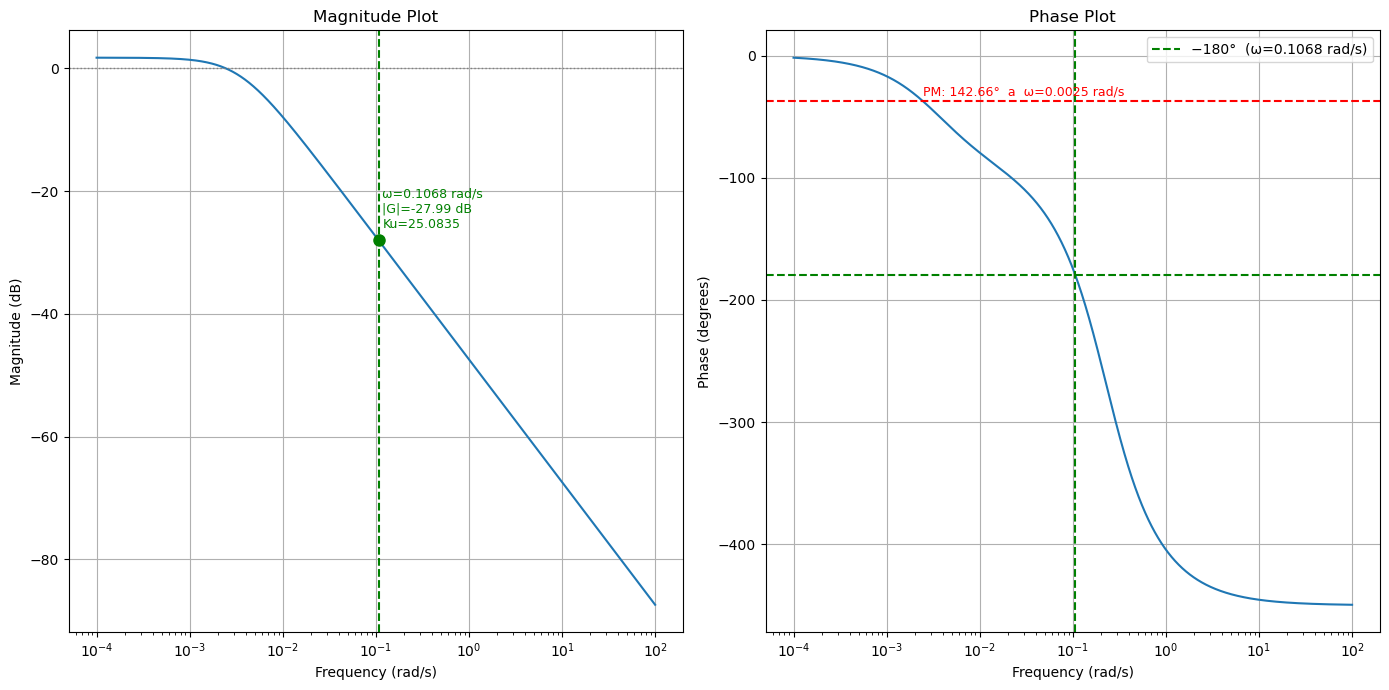

In [25]:
# Planta con tiempo muerto
W = G11 

mag, phase, omega = ct.bode_plot(W, plot=False, omega=np.logspace(-4, 2, 5000))

gm, pm, sm, gc = ct.margin(W)
pm_deg = pm if pm >= 0 else pm + 360

print(f"Phase Margin : {pm_deg:.2f}°  a  ω = {gc:.4f} rad/s")
print(f"Gain Margin  : {gm:.4f} (lineal)  =  {20*np.log10(gm):.2f} dB  a  ω = {sm:.4f} rad/s")
print(f"Ku = {gm:.4f}   wu = {sm:.4f} rad/s   Tu = {2*np.pi/sm:.2f} s")

plt.figure(figsize=(14, 7))

# Magnitude
plt.subplot(1, 2, 1)
plt.semilogx(omega, 20*np.log10(mag))
plt.axhline(y=0, color='gray', linestyle=':', linewidth=1)
# Marcar wu (cruce de fase) en magnitud
mag_at_wu = float(ct.evalfr(W, 1j*sm).__abs__())
plt.axvline(x=sm, color='g', linestyle='--', linewidth=1.5)
plt.plot(sm, 20*np.log10(mag_at_wu), 'go', markersize=8)
plt.text(sm*1.1, 20*np.log10(mag_at_wu)+2,
         f'ω={sm:.4f} rad/s\n|G|={20*np.log10(mag_at_wu):.2f} dB\nKu={gm:.4f}',
         color='green', fontsize=9)
plt.title('Magnitude Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

# Phase
plt.subplot(1, 2, 2)
plt.semilogx(omega, np.rad2deg(phase))
plt.axhline(y=-180, color='g', linestyle='--', linewidth=1.5, label=f'−180°  (ω={sm:.4f} rad/s)')
plt.axhline(y=-180+pm_deg, color='r', linestyle='--', linewidth=1.5)
plt.axvline(x=sm, color='g', linestyle='--', linewidth=1.5)
plt.text(gc, -180+pm_deg+5,
         f'PM: {pm_deg:.2f}°  a  ω={gc:.4f} rad/s',
         color='red', fontsize=9)
plt.title('Phase Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

25.0834823663716


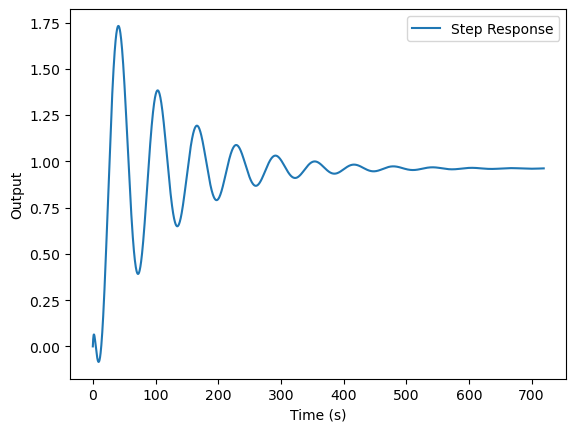

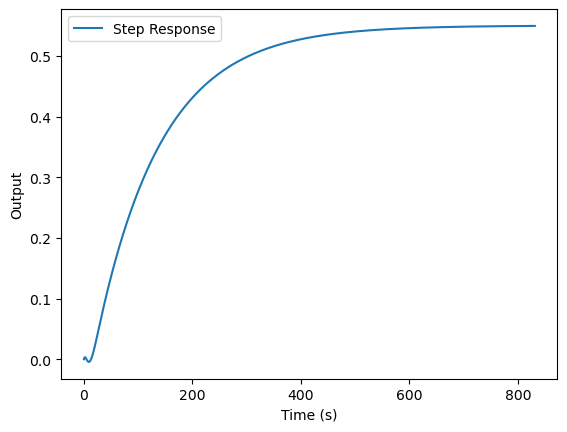

30.6934823663716


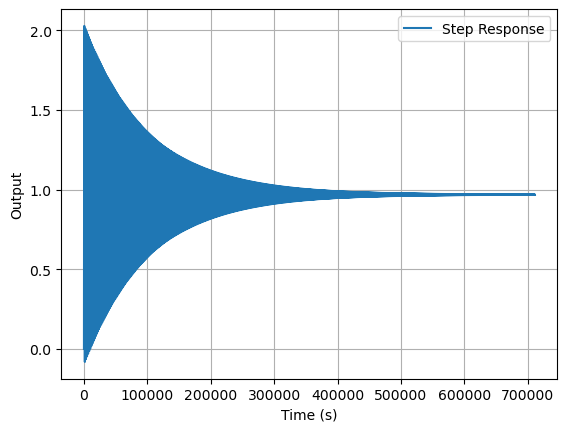

In [26]:
k11Nuevo = gm
print(gm)

G11Nuevo = (k11Nuevo / (tau11*s + 1)) * pade_delay(theta11)

T, y = ct.step_response(ct.feedback(G11Nuevo,1))

plt.figure
plt.plot(T,y,label = 'Step Response')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()
plt.show()

T, y = ct.step_response(ct.feedback(G11,1))

plt.figure
plt.plot(T,y,label = 'Step Response')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()
plt.show()

k11Nuevo = gm + 5.61
print(k11Nuevo)

G11Nuevo = (k11Nuevo / (tau11*s + 1)) * pade_delay(theta11)

T, y = ct.step_response(ct.feedback(G11Nuevo,1))

plt.figure
plt.plot(T,y,label = 'Step Response')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()
#plt.xlim(1190,1500)
plt.grid()
plt.show()

#### Ganancia $G_{22}$

$$
ku = 4.29
$$

$$
Pu = 175
$$

Phase Margin : inf°  a  ω = nan rad/s
Gain Margin  : 5.7858 (lineal)  =  15.25 dB  a  ω = 0.0355 rad/s
Ku = 5.7858   wu = 0.0355 rad/s   Tu = 176.76 s


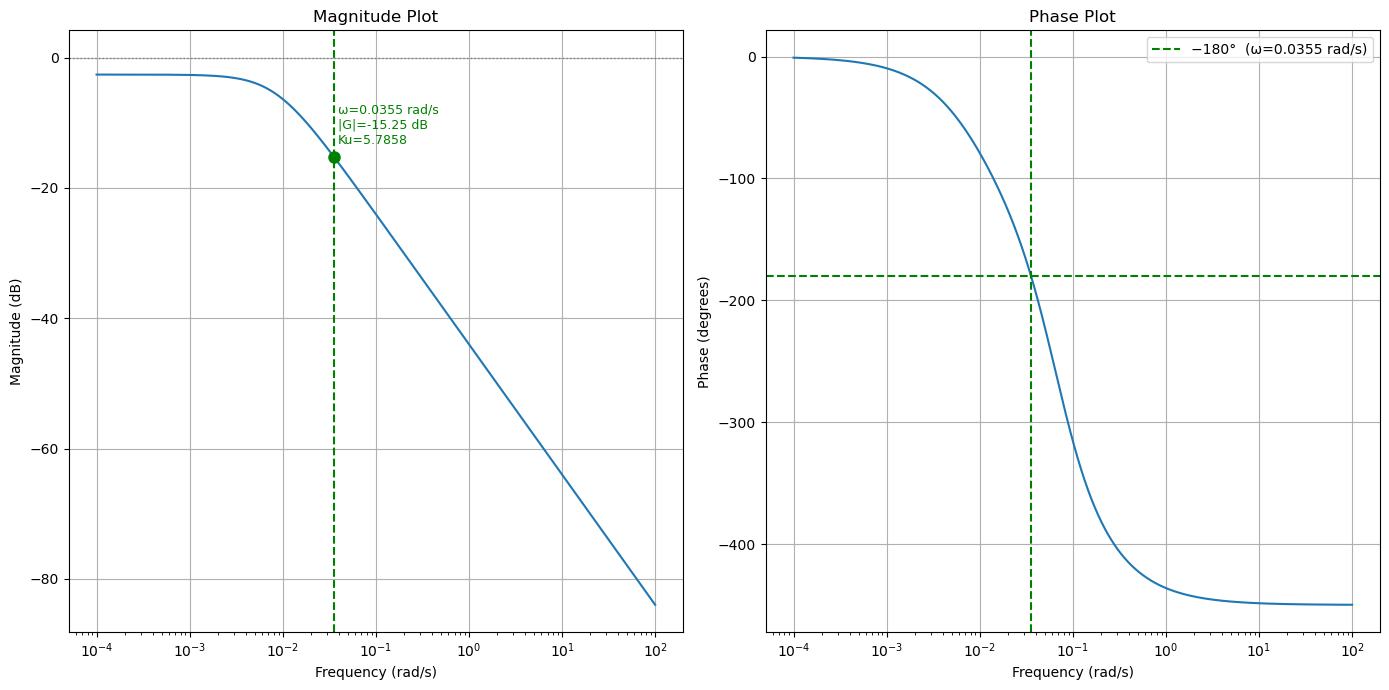

In [27]:
# Planta con tiempo muerto
W = G22

mag, phase, omega = ct.bode_plot(W, plot=False, omega=np.logspace(-4, 2, 5000))

gm, pm, sm, gc = ct.margin(W)
pm_deg = pm if pm >= 0 else pm + 360

print(f"Phase Margin : {pm_deg:.2f}°  a  ω = {gc:.4f} rad/s")
print(f"Gain Margin  : {gm:.4f} (lineal)  =  {20*np.log10(gm):.2f} dB  a  ω = {sm:.4f} rad/s")
print(f"Ku = {gm:.4f}   wu = {sm:.4f} rad/s   Tu = {2*np.pi/sm:.2f} s")

plt.figure(figsize=(14, 7))

# Magnitude
plt.subplot(1, 2, 1)
plt.semilogx(omega, 20*np.log10(mag))
plt.axhline(y=0, color='gray', linestyle=':', linewidth=1)
# Marcar wu (cruce de fase) en magnitud
mag_at_wu = float(ct.evalfr(W, 1j*sm).__abs__())
plt.axvline(x=sm, color='g', linestyle='--', linewidth=1.5)
plt.plot(sm, 20*np.log10(mag_at_wu), 'go', markersize=8)
plt.text(sm*1.1, 20*np.log10(mag_at_wu)+2,
         f'ω={sm:.4f} rad/s\n|G|={20*np.log10(mag_at_wu):.2f} dB\nKu={gm:.4f}',
         color='green', fontsize=9)
plt.title('Magnitude Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

# Phase
plt.subplot(1, 2, 2)
plt.semilogx(omega, np.rad2deg(phase))
plt.axhline(y=-180, color='g', linestyle='--', linewidth=1.5, label=f'−180°  (ω={sm:.4f} rad/s)')
plt.axhline(y=-180+pm_deg, color='r', linestyle='--', linewidth=1.5)
plt.axvline(x=sm, color='g', linestyle='--', linewidth=1.5)
plt.text(gc, -180+pm_deg+5,
         f'PM: {pm_deg:.2f}°  a  ω={gc:.4f} rad/s',
         color='red', fontsize=9)
plt.title('Phase Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

5.785754072543468


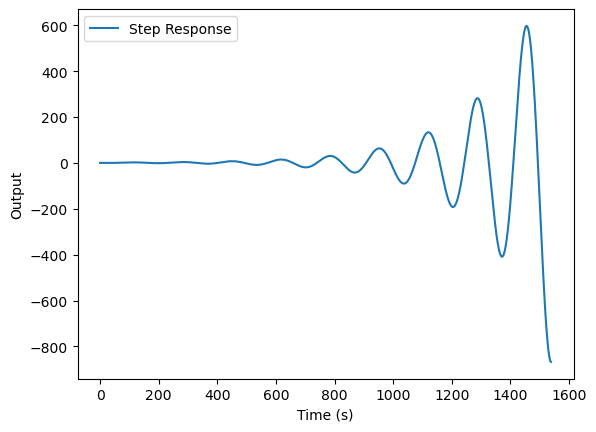

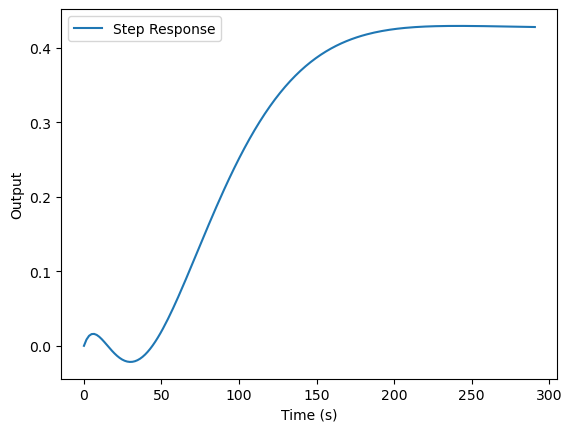

4.285754072543468


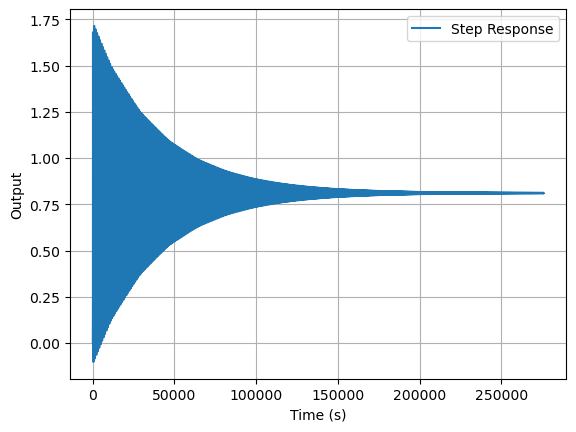

In [28]:
k22Nuevo = gm
print(gm)

G22Nuevo = (k22Nuevo / (tau22*s + 1)) * pade_delay(theta22)

T, y = ct.step_response(ct.feedback(G22Nuevo,1))

plt.figure
plt.plot(T,y,label = 'Step Response')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()
plt.show()

T, y = ct.step_response(ct.feedback(G22,1))

plt.figure
plt.plot(T,y,label = 'Step Response')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()
plt.show()

k22Nuevo = gm - 1.5
print(k22Nuevo)

G22Nuevo = (k22Nuevo / (tau22*s + 1)) * pade_delay(theta22)

T, y = ct.step_response(ct.feedback(G22Nuevo,1))

plt.figure
plt.plot(T,y,label = 'Step Response')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()
#plt.xlim(2016,2191)
plt.grid()
plt.show()

## Diagrama de bloques

Con la ganancia ($ku$) y el periodo de oscilación ($Pu$) se realiza el diagrama de bloques y se simula para diferentes entradas.

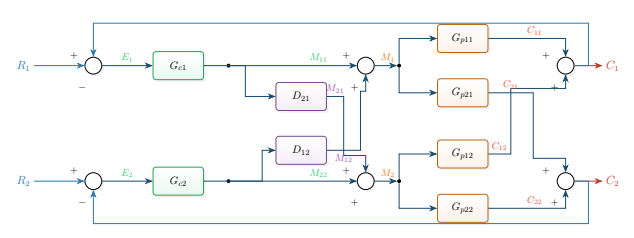

c:\Users\USUARIO\anaconda3\Lib\site-packages\control\statesp.py:1865: FutureWarning: tf2io() is deprecated; use tf2ss() or tf()
  warn("tf2io() is deprecated; use tf2ss() or tf()", FutureWarning)


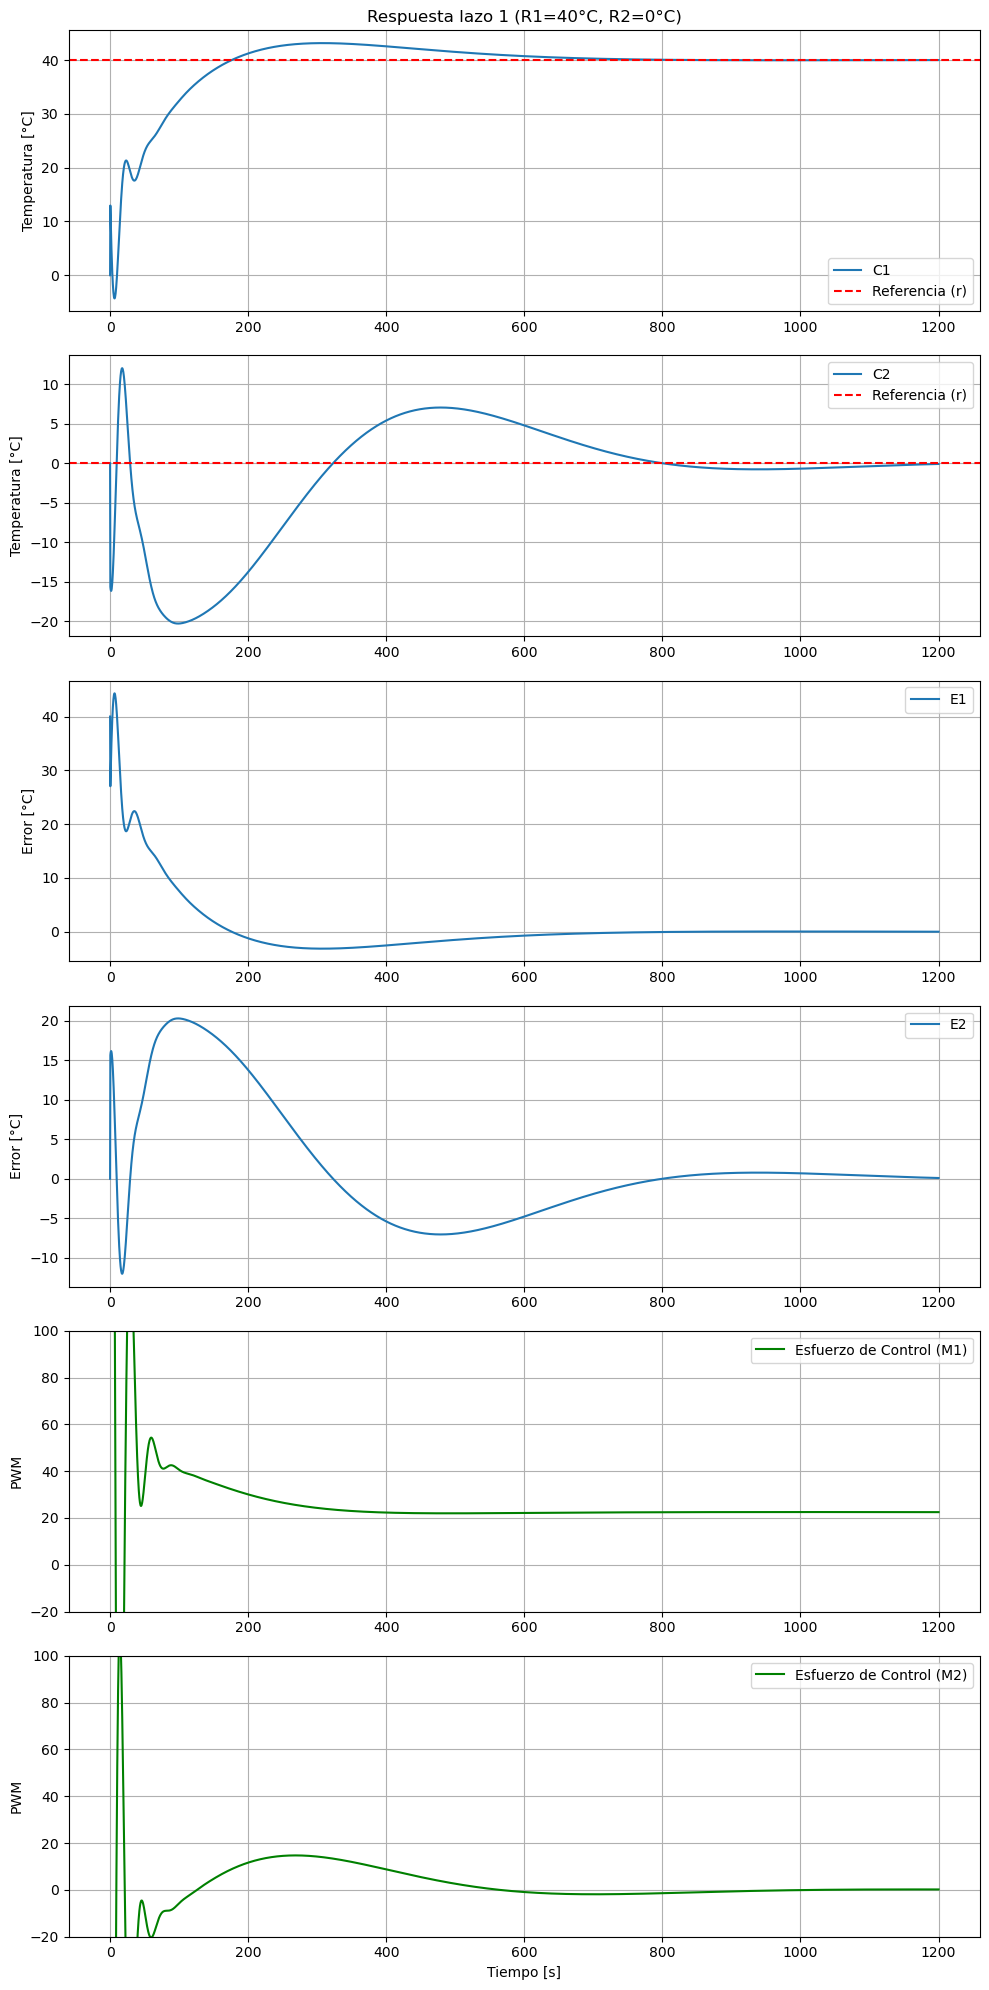

In [29]:
k11Nuevo = 30.69
k22Nuevo = 4.28

# 1. Definir los modelos matemáticos
Pu11 = 310
Kp11 = 0.1 * k11Nuevo  #cambiamos el factor de 0.6 a 0.1
Ti11 = 0.5 * Pu11
Td11 = 0.125 * Pu11

Pu22 = 175
Kp22 = 0.2 * k22Nuevo
Ti22 = 0.5 * Pu22
Td22 = 0.125 * Pu22

# Valor pequeño para T
T1 = 0.01
T2 = 0.01

# Ganancias paralelas
Ki11 = Kp11 / Ti11
Kd11 = Kp11 * Td11

Ki22 = Kp22 / Ti22
Kd22 = Kp22 * Td22

# Controlador PID C1
numC1 = [Kd11 + Kp11*T1,  Kp11 + Ki11*T1,  Ki11]
denC1 = [T1, 1, 0]
C1 = ct.tf(numC1, denC1)

# Controlador PID C2
numC2 = [Kd22 + Kp22*T2,  Kp22 + Ki22*T2,  Ki22]
denC2 = [T2, 1, 0]
C2 = ct.tf(numC2, denC2)

# Desacople
D12 = ct.tf([d12], [1])
D21 = ct.tf([d21], [1])

# 2. Convertir a sistemas I/O con señales nombradas
planta11     = ct.tf2io(G11, name='planta11',     inputs='M1',  outputs='C11')
planta21     = ct.tf2io(G21, name='planta21',     inputs='M1',  outputs='C21')
controlador1 = ct.tf2io(C1,   name='controlador1', inputs='E1',  outputs='M11')
desacople21  = ct.tf2io(D21,  name='desacople21',  inputs='M11', outputs='M21')

planta22     = ct.tf2io(G22, name='planta22',     inputs='M2',  outputs='C22')
planta12     = ct.tf2io(G12, name='planta12',     inputs='M2',  outputs='C12')
controlador2 = ct.tf2io(C2,   name='controlador2', inputs='E2',  outputs='M22')
desacople12  = ct.tf2io(D12,  name='desacople12',  inputs='M22', outputs='M12')

# 3. Crear puntos de suma
sumE1 = ct.summing_junction(inputs=['R1', '-C1'], output='E1')
sumE2 = ct.summing_junction(inputs=['R2', '-C2'], output='E2')
sumM1 = ct.summing_junction(inputs=['M11', 'M12'], output='M1')
sumM2 = ct.summing_junction(inputs=['M22', 'M21'], output='M2')
sumC1 = ct.summing_junction(inputs=['C11', 'C21'], output='C1')
sumC2 = ct.summing_junction(inputs=['C22', 'C12'], output='C2')

# 4. Interconectar el sistema
# Especificamos que 'r' (referencia) es la entrada global.
# Especificamos que queremos registrar 'y', 'u' y 'e' como salidas.
sys_closed = ct.interconnect(
    [planta11,planta21, controlador1, desacople21, planta22, planta12, controlador2, desacople12, sumE1, sumE2, sumM1, sumM2, sumC1, sumC2],
    inplist=['R1', 'R2'],
    outlist=['C1', 'C2', 'E1', 'E2', 'M1', 'M2']
)

# 5. Simular la respuesta al escalón (Ej: cambio de 10 cm en la referencia)
time = np.linspace(0, 1200, 3000)
t, outputs = ct.step_response(sys_closed, T=time)

# Escalar por la magnitud del escalon (40)
C1 = np.squeeze(outputs[0]) * 40
C2 = np.squeeze(outputs[1]) * 40
E1 = np.squeeze(outputs[2]) * 40
E2 = np.squeeze(outputs[3]) * 40
M1 = np.squeeze(outputs[4]) * 40
M2 = np.squeeze(outputs[5]) * 40

# 6. Graficar los resultados
plt.figure(figsize=(10, 20))

plt.subplot(6, 1, 1)
plt.title("Respuesta lazo 1 (R1=40°C, R2=0°C)")

plt.plot(t, C1[0], label='C1')
plt.axhline(40, color='r', linestyle='--', label='Referencia (r)')
plt.ylabel('Temperatura [°C]')
plt.legend()
plt.grid()

plt.subplot(6, 1, 2)
plt.plot(t, C2[0], label='C2')
plt.axhline(0, color='r', linestyle='--', label='Referencia (r)')
plt.ylabel('Temperatura [°C]')
plt.legend()
plt.grid()

plt.subplot(6, 1, 3)
plt.plot(t, E1[0], label='E1')
plt.ylabel('Error [°C]')
plt.legend()
plt.grid()

plt.subplot(6, 1, 4)
plt.plot(t, E2[0], label='E2')
plt.ylabel('Error [°C]')
plt.legend()
plt.grid()

plt.subplot(6, 1, 5)
plt.plot(t, M1[0], color='green', label='Esfuerzo de Control (M1)')
plt.ylabel('PWM')
plt.ylim(-20,100)
plt.legend()
plt.grid()

plt.subplot(6, 1, 6)
plt.plot(t, M2[0], color='green', label='Esfuerzo de Control (M2)')
plt.xlabel('Tiempo [s]')
plt.ylabel('PWM')
plt.ylim(-20,100)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

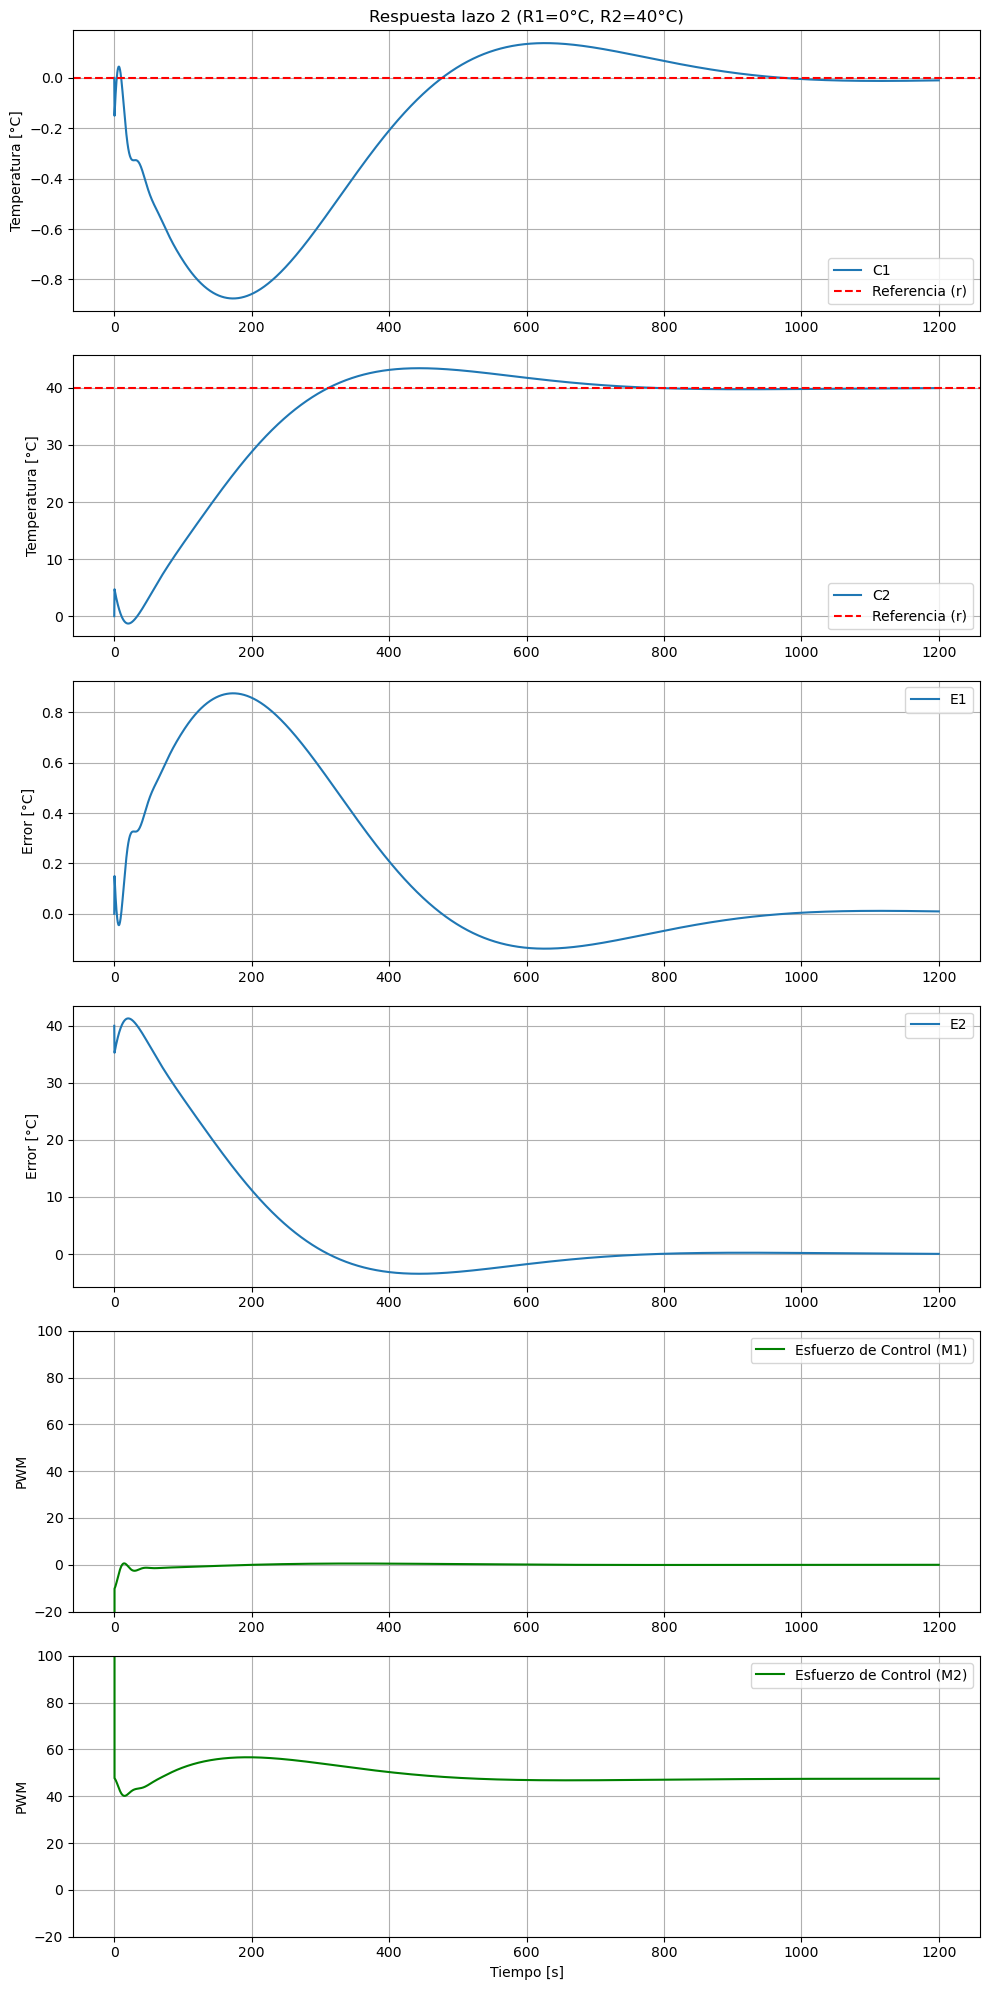

In [36]:
# 6. Graficar los resultados
plt.figure(figsize=(10, 20))

plt.subplot(6, 1, 1)
plt.title( "Respuesta lazo 2 (R1=0°C, R2=40°C)")

plt.plot(t, C1[1], label='C1')
plt.axhline(0, color='r', linestyle='--', label='Referencia (r)')
plt.ylabel('Temperatura [°C]')
plt.legend()
plt.grid()

plt.subplot(6, 1, 2)
plt.plot(t, C2[1], label='C2')
plt.axhline(40, color='r', linestyle='--', label='Referencia (r)')
plt.ylabel('Temperatura [°C]')
plt.legend()
plt.grid()

plt.subplot(6, 1, 3)
plt.plot(t, E1[1], label='E1')
plt.ylabel('Error [°C]')
plt.legend()
plt.grid()

plt.subplot(6, 1, 4)
plt.plot(t, E2[1], label='E2')
plt.ylabel('Error [°C]')
plt.legend()
plt.grid()

plt.subplot(6, 1, 5)
plt.plot(t, M1[1], color='green', label='Esfuerzo de Control (M1)')
plt.ylabel('PWM')
plt.ylim(-20,100)
plt.legend()
plt.grid()

plt.subplot(6, 1, 6)
plt.plot(t, M2[1], color='green', label='Esfuerzo de Control (M2)')
plt.xlabel('Tiempo [s]')
plt.ylabel('PWM')
plt.ylim(-20,100)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

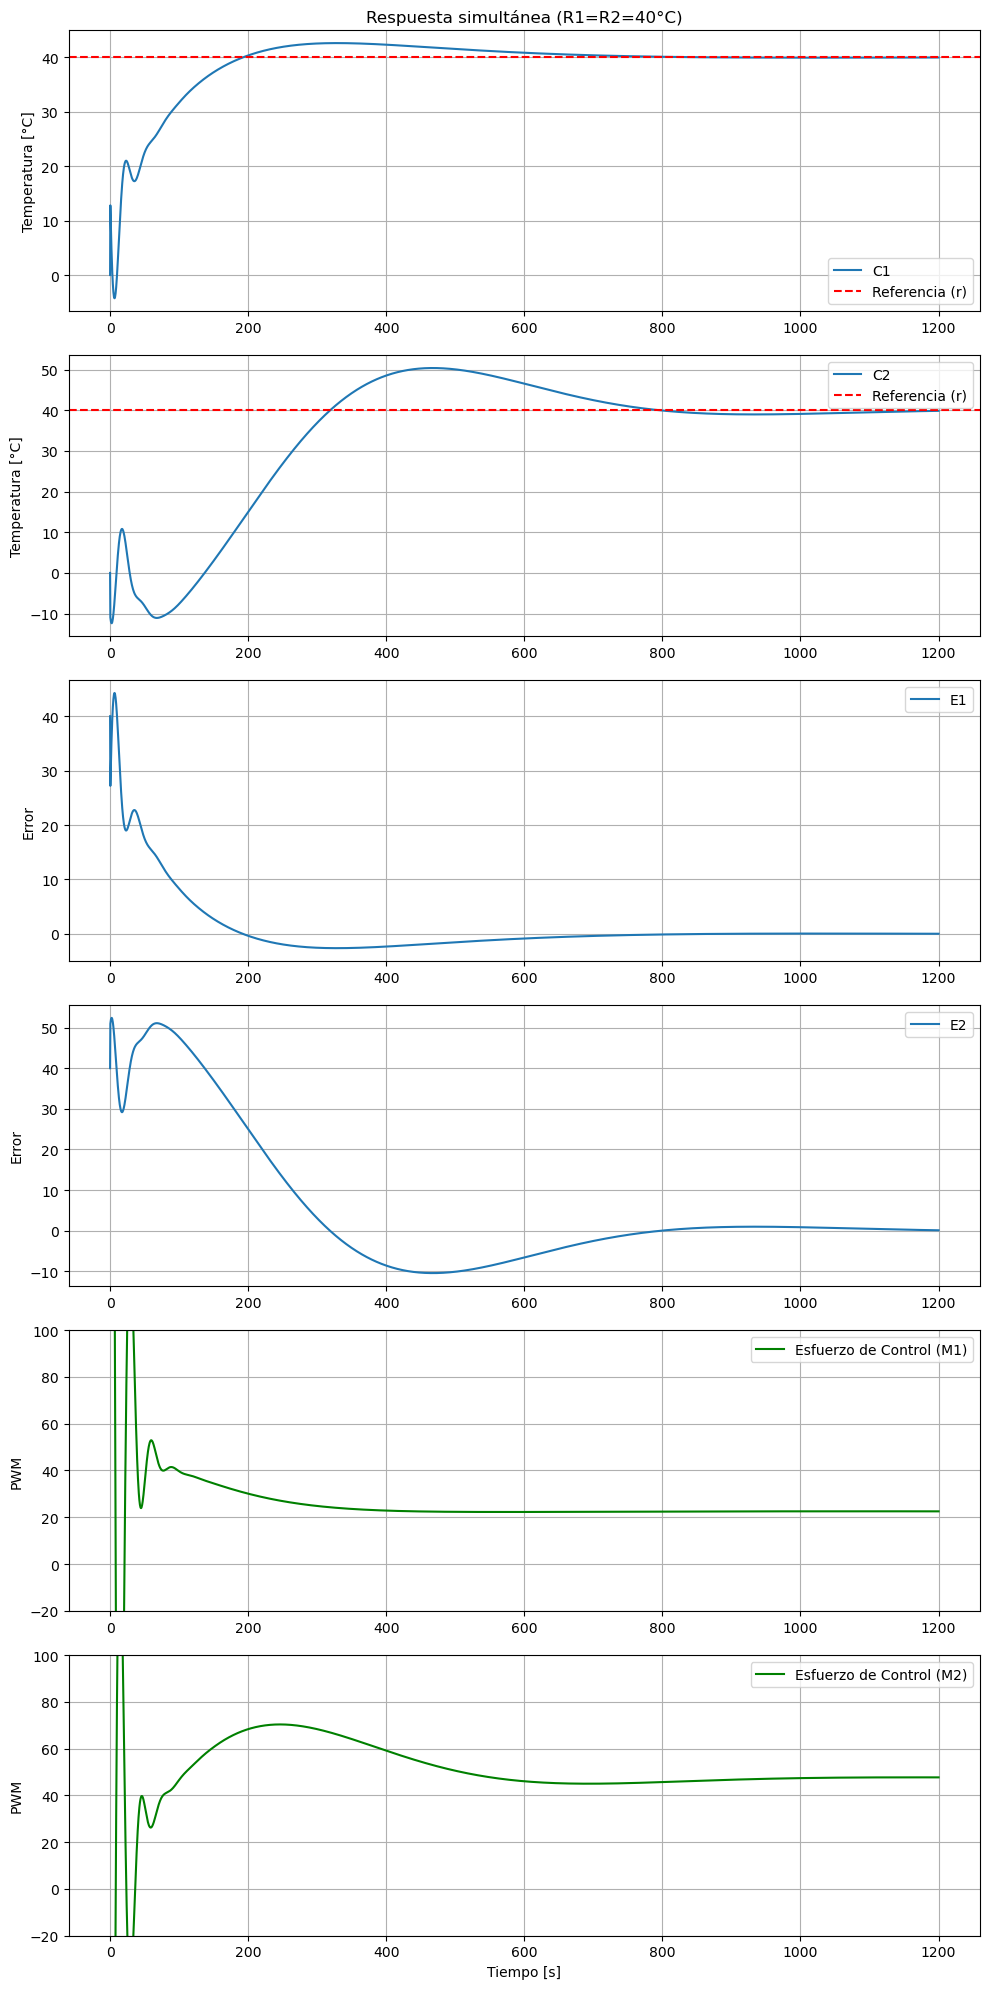

In [31]:
# Escalón de amplitud 20 en ambas entradas simultáneamente
U = np.ones((2, len(time))) * 40

t_sim, y_sim = ct.forced_response(sys_closed, T=time, U=U)

C1_sim = np.squeeze(y_sim[0])
C2_sim = np.squeeze(y_sim[1])
E1_sim = np.squeeze(y_sim[2])
E2_sim = np.squeeze(y_sim[3])
M1_sim = np.squeeze(y_sim[4])
M2_sim = np.squeeze(y_sim[5])

plt.figure(figsize=(10, 20))

plt.subplot(6, 1, 1)
plt.title("Respuesta simultánea (R1=R2=40°C)")

plt.plot(t_sim, C1_sim, label='C1')
plt.axhline(40, color='r', linestyle='--', label='Referencia (r)')
plt.ylabel('Temperatura [°C]')
plt.legend()
plt.grid()

plt.subplot(6, 1, 2)
plt.plot(t_sim, C2_sim, label='C2')
plt.axhline(40, color='r', linestyle='--', label='Referencia (r)')
plt.ylabel('Temperatura [°C]')
plt.legend()
plt.grid()

plt.subplot(6, 1, 3)
plt.plot(t_sim, E1_sim, label='E1')
plt.ylabel('Error')
plt.legend()
plt.grid()

plt.subplot(6, 1, 4)
plt.plot(t_sim, E2_sim, label='E2')
plt.ylabel('Error')
plt.legend()
plt.grid()

plt.subplot(6, 1, 5)
plt.plot(t_sim, M1_sim, color='green', label='Esfuerzo de Control (M1)')
plt.ylabel('PWM')
plt.ylim(-20,100)
plt.legend()
plt.grid()

plt.subplot(6, 1, 6)
plt.plot(t_sim, M2_sim, color='green', label='Esfuerzo de Control (M2)')
plt.xlabel('Tiempo [s]')
plt.ylabel('PWM')
plt.ylim(-20,100)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

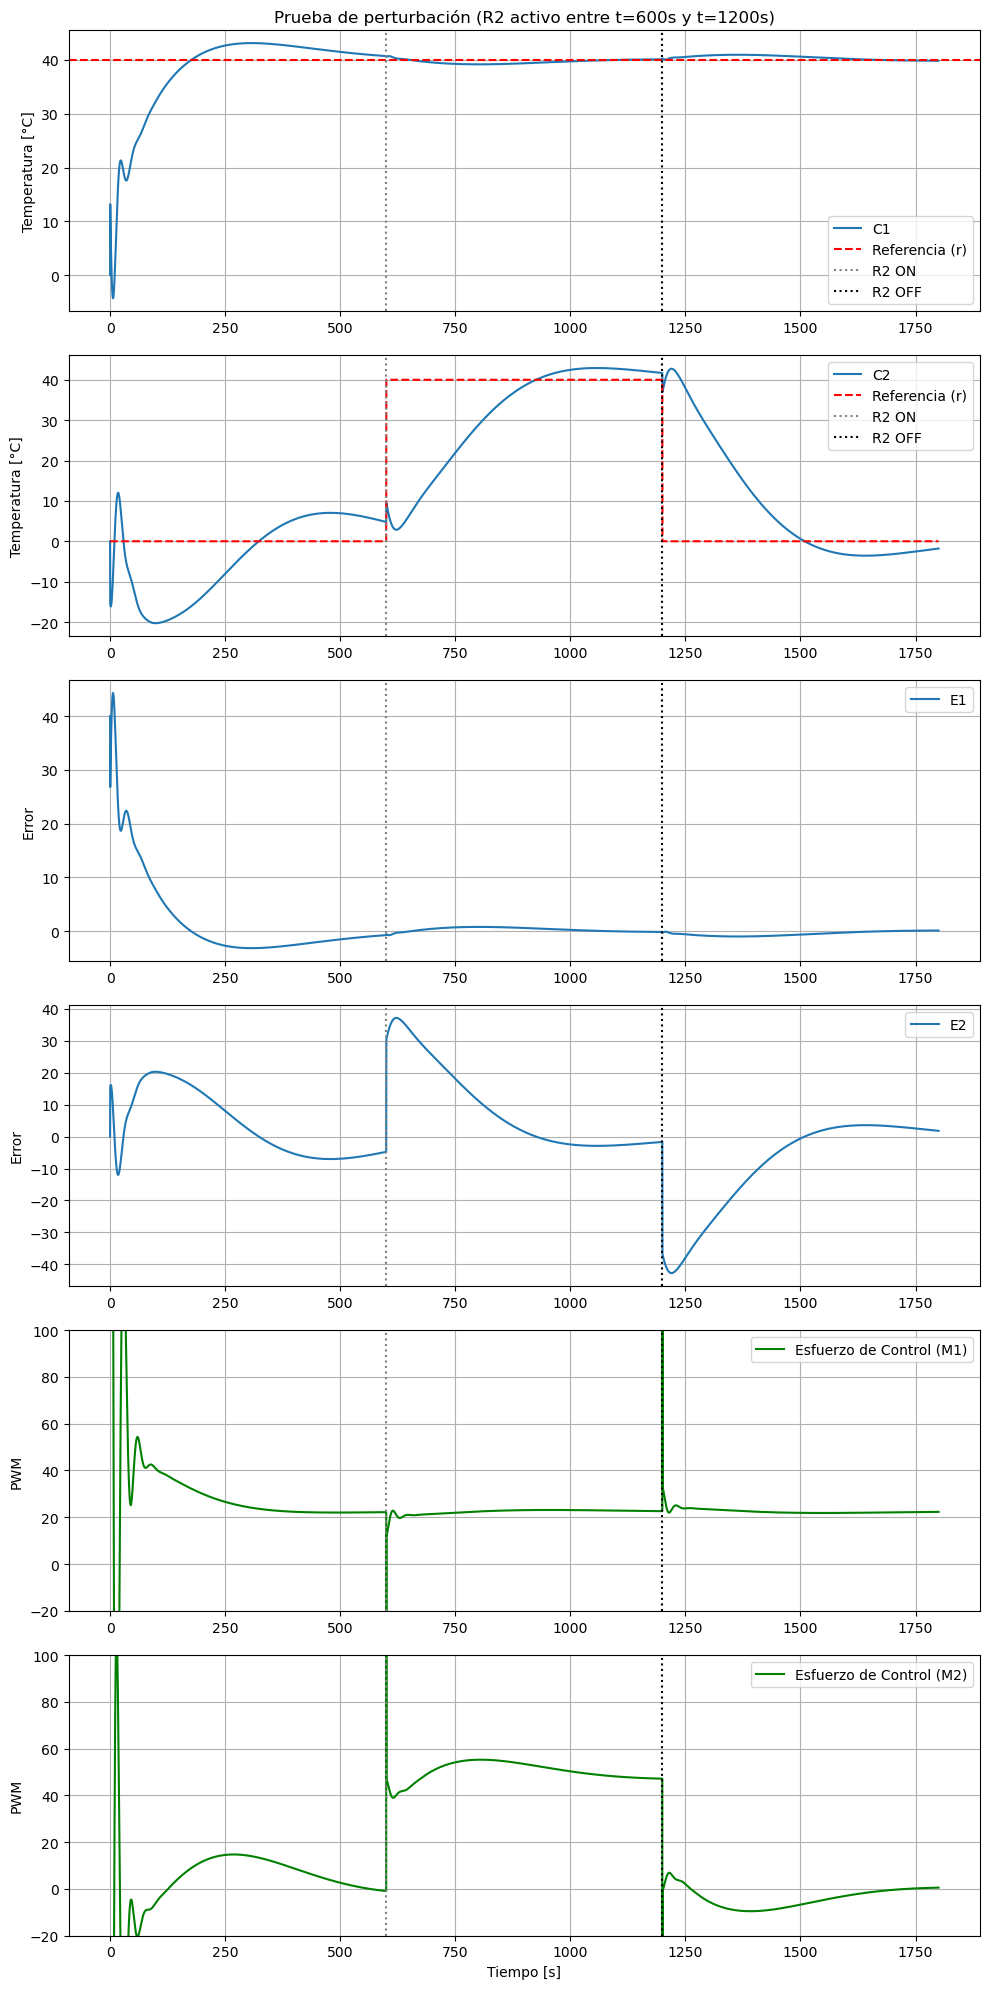

In [34]:
time = np.linspace(0, 1800, 5000)  # más tiempo para ver todo

# R1 sube a 40°C desde t=0 y se queda
# R2 sube a 40°C desde t=600s hasta t=1200s, luego vuelve a 0°C
U = np.zeros((2, len(time)))

# R1 siempre en 40
U[0, :] = 40

# R2 sube en t=600s y baja en t=1200s
t_subida_R2  = 600
t_bajada_R2  = 1200
U[1, time >= t_subida_R2]  = 40
U[1, time >= t_bajada_R2]  = 0

t_sim, y_sim = ct.forced_response(sys_closed, T=time, U=U)

C1_sim = np.squeeze(y_sim[0])
C2_sim = np.squeeze(y_sim[1])
E1_sim = np.squeeze(y_sim[2])
E2_sim = np.squeeze(y_sim[3])
M1_sim = np.squeeze(y_sim[4])
M2_sim = np.squeeze(y_sim[5])

# Referencia dinámica para C2 (0 antes de t=600s, 20 después)
ref_C2 = np.zeros(len(time))
ref_C2[time >= t_subida_R2] = 40
ref_C2[time >= t_bajada_R2] = 0

plt.figure(figsize=(10, 20))

plt.subplot(6, 1, 1)
plt.title("Prueba de perturbación (R2 activo entre t=600s y t=1200s)")
plt.plot(t_sim, C1_sim, label='C1')
plt.axhline(40, color='r', linestyle='--', label='Referencia (r)')
plt.axvline(t_subida_R2, color='gray', linestyle=':', label='R2 ON')
plt.axvline(t_bajada_R2, color='black', linestyle=':', label='R2 OFF')
plt.ylabel('Temperatura [°C]')
plt.legend()
plt.grid()

plt.subplot(6, 1, 2)
plt.plot(t_sim, C2_sim, label='C2')
plt.plot(t_sim, ref_C2, color='r', linestyle='--', label='Referencia (r)')  # ← línea dinámica
plt.axvline(t_subida_R2, color='gray',  linestyle=':', label='R2 ON')
plt.axvline(t_bajada_R2, color='black', linestyle=':', label='R2 OFF')
plt.ylabel('Temperatura [°C]')
plt.legend()
plt.grid()

plt.subplot(6, 1, 3)
plt.plot(t_sim, E1_sim, label='E1')
plt.axvline(t_subida_R2, color='gray', linestyle=':')
plt.axvline(t_bajada_R2, color='black', linestyle=':')
plt.ylabel('Error')
plt.legend()
plt.grid()

plt.subplot(6, 1, 4)
plt.plot(t_sim, E2_sim, label='E2')
plt.axvline(t_subida_R2, color='gray', linestyle=':')
plt.axvline(t_bajada_R2, color='black', linestyle=':')
plt.ylabel('Error')
plt.legend()
plt.grid()

plt.subplot(6, 1, 5)
plt.plot(t_sim, M1_sim, color='green', label='Esfuerzo de Control (M1)')
plt.axvline(t_subida_R2, color='gray', linestyle=':')
plt.axvline(t_bajada_R2, color='black', linestyle=':')
plt.ylabel('PWM')
plt.ylim(-20,100)
plt.legend()
plt.grid()

plt.subplot(6, 1, 6)
plt.plot(t_sim, M2_sim, color='green', label='Esfuerzo de Control (M2)')
plt.axvline(t_subida_R2, color='gray', linestyle=':')
plt.axvline(t_bajada_R2, color='black', linestyle=':')
plt.xlabel('Tiempo [s]')
plt.ylabel('PWM')
plt.ylim(-20,100)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

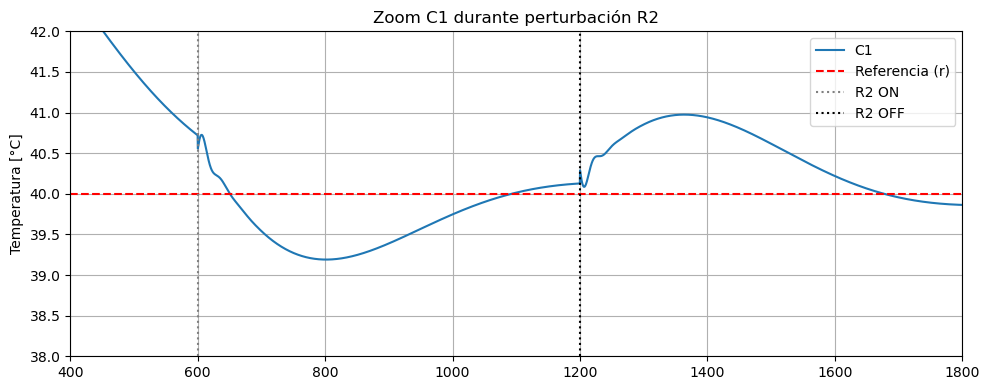

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(t_sim, C1_sim, label='C1')
plt.axhline(40, color='r', linestyle='--', label='Referencia (r)')
plt.axvline(600,  color='gray',  linestyle=':', label='R2 ON')
plt.axvline(1200, color='black', linestyle=':', label='R2 OFF')
plt.xlim(400, 1800)        # zoom en la zona de perturbación
plt.ylim(38, 42)           # zoom vertical para ver pequeñas variaciones
plt.title("Zoom C1 durante perturbación R2")
plt.ylabel('Temperatura [°C]')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

El sistema de control multivariable con desacople estático y dos PIDs independientes logra regular ambas temperaturas a la referencia con buen rechazo de perturbaciones, manteniendo la interacción entre lazos por debajo de ±1°C.

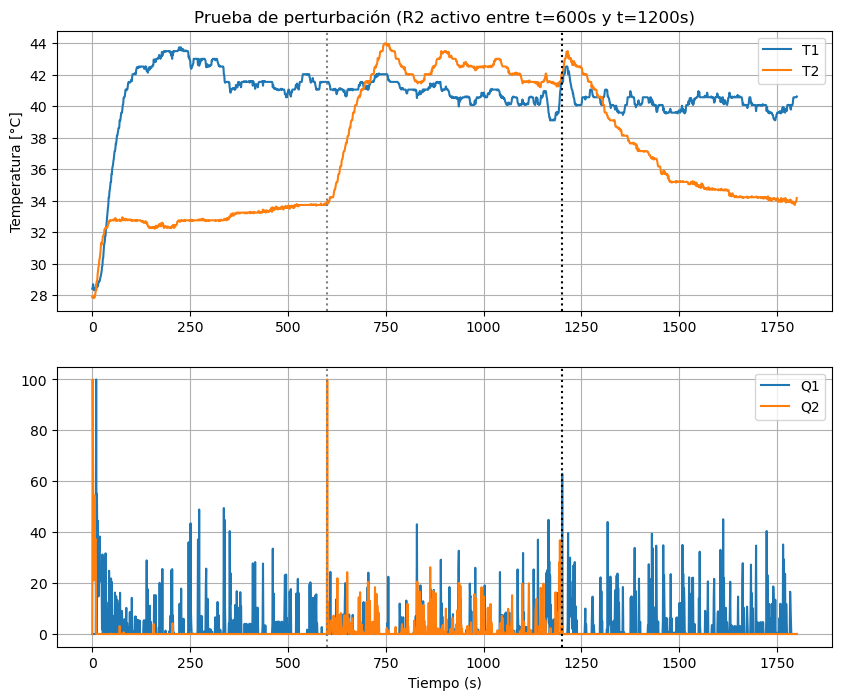

In [45]:
ruta = "data_plantareal_dos_perturbaciones.txt"
data = pd.read_csv(ruta, encoding='latin1', sep=',')

# R2 sube en t=600s y baja en t=1200s
t_subida_R2  = 600
t_bajada_R2  = 1200

# Referencia dinámica para C2 (0 antes de t=600s, 20 después)
ref_C2 = np.zeros(len(time))
ref_C2[time >= t_subida_R2] = 40
ref_C2[time >= t_bajada_R2] = 0

t = data["Tiempo (s)"]
tempQ1 = data[" Temp1 (°C)"]
tempQ2 = data[" Temp2 (°C)"]
u1 = data[" Cal1 (%)"]
u2 = data[" Cal2 (%)"]

plt.figure(figsize=(10,8))

plt.subplot(2, 1, 1)
plt.title("Prueba de perturbación (R2 activo entre t=600s y t=1200s)")
plt.plot(t,tempQ1,label="T1")
plt.plot(t,tempQ2,label="T2")
plt.axvline(t_subida_R2, color='gray', linestyle=':')
plt.axvline(t_bajada_R2, color='black', linestyle=':')
plt.ylabel('Temperatura [°C]')
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(t,u1,label="Q1")
plt.plot(t,u2,label="Q2")
plt.axvline(t_subida_R2, color='gray', linestyle=':')
plt.axvline(t_bajada_R2, color='black', linestyle=':')
plt.xlabel("Tiempo (s)")

plt.legend()
plt.grid()

plt.show()